# Reaction Time Changes Across Rounds Before and After the 2010 Zero-Tolerance False Start Rule

무관용 부정출발 규정(2010년) 전후로 올림픽 100 m 결승 진출자의 **라운드 간 반응속도 변화 폭**이 달라졌는지 비교한다.

| 시기 | 대회 | 비교 라운드 |
|---|---|---|
| Pre-ZTR | 2004, 2008 | Quarter → Semi → Final |
| Post-ZTR | 2012, 2016 | Heats → Semi → Final |

- 두 시기 모두 **결승 전 마지막 세 경기**를 1라운드(R1), 준결승(Semi), 결승(Final)으로 맞춘다.
- 변화 폭 = 뒤 라운드 − 앞 라운드. **음수이면 뒤 라운드에서 반응이 빨라졌다**는 뜻이다.
- 시기 간 반응속도 *수준* 차이는 출발 장비 기준 변화가 섞여 있으므로 해석하지 않고, 라운드 간 *변화 폭*만 해석한다.

**데이터**: Mirshams Shahshahani, P. (2018). *Downloaded IAAF Sprint Results in all Heats for 2004 - 2016 Olympics for both Men and Women* [Data set]. University of Michigan - Deep Blue Data. https://doi.org/10.7302/Z20V8B11

**실행 환경**: Python 3.12, `pandas`, `numpy`, `scipy`, `matplotlib`, `pingouin`, `openpyxl`
```
pip install pandas numpy scipy matplotlib pingouin openpyxl
```

## 0. 설정

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import pingouin as pg
from matplotlib.ticker import MultipleLocator

plt.rc('font', family='AppleGothic')   # 한글 글꼴 (Windows: 'Malgun Gothic')
plt.rc('axes', unicode_minus=False)

DATA_PATH = 'data_96_16_100.xlsx'
TARGET_YEARS = [2004, 2008, 2012, 2016]
ERA_BY_YEAR = {2004: 'Pre', 2008: 'Pre', 2012: 'Post', 2016: 'Post'}
ERA_ORDER = ['Pre', 'Post']

# 시기별 원래 라운드 이름 -> 공통 라운드 이름
ROUNDS_BY_ERA = {
    'Pre':  {'Quarter': 'R1', 'Semi': 'Semi', 'Final': 'Final'},
    'Post': {'Heats':   'R1', 'Semi': 'Semi', 'Final': 'Final'},
}
ROUND_ORDER = ['R1', 'Semi', 'Final']
ROUND_LABEL = {'R1': '1라운드', 'Semi': '준결승', 'Final': '결승'}
GENDER_GROUPS = [('전체', None), ('남자', 'M'), ('여자', 'F')]

# 변화 폭 열 이름: (앞 라운드, 뒤 라운드, 표시 이름)
CHANGE_COLS = {
    'd_total': ('R1', 'Final', '전체 변화 (결승 − 1라운드)'),
    'd_front': ('R1', 'Semi',  '앞 구간 변화 (준결승 − 1라운드)'),
    'd_back':  ('Semi', 'Final', '뒤 구간 변화 (결승 − 준결승)'),
}

INVALID_MARK_PATTERN = r'DQ|DNF|DNS'   # 실격, 기권, 불참
ALPHA = 0.05

## 공통 함수

In [ ]:
# ---------- 데이터 정리 ----------
def normalize_country_code(code):
    """중복된 국가 코드 정리 (예: 'USAUSA' -> 'USA')"""
    code = str(code).strip()
    half = len(code) // 2
    return code[:half] if len(code) % 2 == 0 and code[:half] == code[half:] else code


def load_and_preprocess(path, rounds_by_era):
    """100 m, 대상 연도, 대상 라운드만 남기고 DQ/DNF/DNS 행을 뺀 뒤 반응속도를 ms로 바꿈"""
    df = pd.read_excel(path)
    df['COUNTRY'] = df['COUNTRY'].apply(normalize_country_code)
    df = df[(df['Race'] == '100 m') & (df['Year'].isin(TARGET_YEARS))].copy()
    df['Era'] = df['Year'].map(ERA_BY_YEAR)

    df['Round_Group'] = [rounds_by_era[e].get(r) for e, r in zip(df['Era'], df['Round'])]
    df = df.dropna(subset=['Round_Group'])

    # 'DQ RIAAF 162.7' 같은 표기가 숫자로 바뀌지 않도록 먼저 제거
    is_invalid = df['MARK'].astype(str).str.contains(INVALID_MARK_PATTERN, regex=True)
    removed = df[is_invalid]
    df = df[~is_invalid]

    df['MARK_sec'] = pd.to_numeric(df['MARK'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
    df['Rxn_ms'] = df['RxnTime'] * 1000
    df = df.dropna(subset=['MARK_sec', 'Rxn_ms']).copy()
    df['Round_Group'] = pd.Categorical(df['Round_Group'], categories=ROUND_ORDER, ordered=True)
    return df, removed


def extract_finalists(df):
    """결승에 오른 [선수, 연도]의 모든 라운드 기록"""
    keys = df.loc[df['Round_Group'] == 'Final', ['ATHLETE', 'Year']].drop_duplicates()
    return df.merge(keys, on=['ATHLETE', 'Year'])


def build_change_table(df, required_rounds):
    """선수(+연도)당 한 줄로 바꾸고 라운드 간 변화 폭 계산. required_rounds 기록이 모두 있는 선수만 남김"""
    wide = df.pivot_table(index=['ATHLETE', 'Year', 'Gender', 'Era'], columns='Round_Group',
                          values='Rxn_ms', aggfunc='first', observed=False)
    wide.columns = [str(c) for c in wide.columns]
    wide = wide.dropna(subset=required_rounds).reset_index()
    for col, (start, end, _) in CHANGE_COLS.items():
        if start in wide.columns and end in wide.columns:
            wide[col] = wide[end] - wide[start]
    return wide


# ---------- 통계 ----------
def format_p_value(p):
    return f"{p:.4f}" if p >= 0.0001 else "< 0.0001"


def cohens_d(x, y):
    """독립 두 집단 Cohen's d = (x 평균 − y 평균) / 합동 표준편차"""
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.std(ddof=1) ** 2 + (ny - 1) * y.std(ddof=1) ** 2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd


def rank_biserial_paired(x):
    """윌콕슨 부호순위 검정의 효과크기 (음수 = 감소 방향)"""
    nz = x[x != 0]
    n = len(nz)
    if n == 0:
        return np.nan
    r_plus = nz.abs().rank()[nz > 0].sum()
    return 2 * r_plus / (n * (n + 1) / 2) - 1


def test_vs_zero(x):
    """변화 폭이 0과 다른지 검정
    정규성 만족 -> 1표본 t검정(= 대응표본 t검정), 효과크기 dz / 위배 -> 윌콕슨 부호순위, 효과크기 r"""
    if stats.shapiro(x).pvalue >= ALPHA:
        stat, p = stats.ttest_1samp(x, 0)
        return '대응표본 t검정', stat, p, "Cohen's dz", x.mean() / x.std(ddof=1)
    res = stats.wilcoxon(x)
    return '윌콕슨 부호순위', res.statistic, res.pvalue, '순위 상관 r', rank_biserial_paired(x)

## 1. 분석 대상 선정
- 2004~2016년 올림픽 남녀 100 m, DQ/DNF/DNS 기록 제외
- 결승 진출자 중 **세 라운드 반응속도가 모두 있는 선수**만 분석 (모든 분석에서 같은 선수 사용)

In [ ]:
race_df, removed_df = load_and_preprocess(DATA_PATH, ROUNDS_BY_ERA)
finalist_df = extract_finalists(race_df)
change_df = build_change_table(finalist_df, required_rounds=['R1', 'Semi', 'Final'])
finalist_complete_df = finalist_df.merge(change_df[['ATHLETE', 'Year']], on=['ATHLETE', 'Year'])

print(f"[제외된 DQ/DNF/DNS 행] {len(removed_df)}건")
display(removed_df[['ATHLETE', 'Year', 'Gender', 'Round', 'MARK']])

print("\n[전체 선수: 시기 x 성별 x 라운드 인원]")
display(race_df.pivot_table(index=['Era', 'Gender'], columns='Round_Group', values='Rxn_ms',
                            aggfunc='count', observed=False).reindex(ERA_ORDER, level=0))

print("\n[결승 진출자: 시기 x 성별 x 라운드 인원]")
display(finalist_df.pivot_table(index=['Era', 'Gender'], columns='Round_Group', values='Rxn_ms',
                                aggfunc='count', observed=False).reindex(ERA_ORDER, level=0))

print("\n[최종 분석 대상: 세 라운드 반응속도가 모두 있는 결승 진출자 수]")
display(change_df.groupby(['Era', 'Gender']).size().unstack().reindex(ERA_ORDER))

[제외된 DQ/DNF/DNS 행] 20건


,ATHLETE,Year,Gender,Round,MARK
103,Samuel FRANCIS,2008,M,Quarter,DQ
127,Samuel FRANCIS,2008,M,Semi,DQ
536,Semoy HACKETT,2012,F,Heats,DQ
552,Semoy HACKETT,2012,F,Semi,DQ
613,Tyson GAY,2012,M,Heats,DQ
637,Idrissa ADAM,2012,M,Heats,DNF
661,Kim COLLINS,2012,M,Heats,DNS
684,Tyson GAY,2012,M,Semi,DQ
685,Kemar HYMAN,2012,M,Semi,DNS
693,Tyson GAY,2012,M,Final,DQ



[전체 선수 - 시기 x 성별 x 라운드 인원]


Round_Group   R1  Semi  Final
Era  Gender                  
Pre  F        69    31     16
     M        78    31     15
Post F       119    46     16
     M       122    44     15


[결승 진출자 - 시기 x 성별 x 라운드 인원]


Round_Group  R1  Semi  Final
Era  Gender                 
Pre  F       15    16     16
     M       15    15     15
Post F       16    16     16
     M       15    15     15


[최종 분석 대상 - 세 라운드 반응속도가 모두 있는 결승 진출자 수]


Gender,F,M
Era,,
Pre,15,15
Post,16,15


In [ ]:
# 대상 선정 단계별 건수 (논문 대상 선정 흐름도용)
raw = pd.read_excel(DATA_PATH)
print("① 전체 자료:", len(raw))
print("   연도별:", raw['Year'].value_counts().sort_index().to_dict())
print("   종목별:", raw['Race'].value_counts().to_dict())

print("\n[참고] 연도별 반응속도 결측 비율과 평균(ms)")
display(raw.groupby('Year')['RxnTime'].agg(결측비율=lambda s: s.isna().mean().round(2),
                                          평균_ms=lambda s: round(s.mean() * 1000, 1)))

step2 = raw[(raw['Race'] == '100 m') & (raw['Year'].isin(TARGET_YEARS))]
print("\n② 2004~2016년 100 m:", len(step2))
print("③ 반응속도 결측 제외:", len(step2.dropna(subset=['RxnTime'])))
print("④ 결승 진출자의 세 라운드 기록 (DQ/DNF/DNS 제외):", len(finalist_df))
print("⑤ 세 라운드 반응속도가 모두 있는 결승 진출 기록:", len(change_df),
      f"(실제 선수 {change_df['ATHLETE'].nunique()}명)")

① 전체 자료: 2457
   연도별: {1996: 272, 2000: 493, 2004: 433, 2008: 456, 2012: 406, 2016: 397}
   종목별: {'100 m': 1510, '110 m H': 529, '100 m H': 418}

[참고] 연도별 반응속도 결측 비율과 평균(ms)


,결측비율,평균_ms
Year,,
1996,1.00,NaN
2000,0.05,196.1
2004,0.04,173.0
2008,0.01,172.1
2012,0.02,164.7
2016,0.02,148.8



② 2004~2016년 100m: 1042
③ 반응속도 결측 제외: 1023
④ 결승 진출자의 세 라운드 기록(DQ/DNF/DNS 제외): 185
⑤ 세 라운드 반응속도가 모두 있는 결승 진출 기록: 61 (실제 선수 46명)


## 2. 라운드별 평균 반응속도
- 오차막대 = 표준오차, 세 그래프의 세로축은 같게 맞춤
- 선의 높이(시기 간 수준 차이)는 해석하지 않고 **기울기**만 본다.

In [ ]:
def get_round_trend_values(df):
    """시기 x 성별 x 라운드별 N, 평균, 표준편차, 표준오차"""
    rows = []
    for g_name, g in GENDER_GROUPS:
        for era in ERA_ORDER:
            for r in ROUND_ORDER:
                s = df[(df['Era'] == era) & (df['Round_Group'] == r)]
                if g:
                    s = s[s['Gender'] == g]
                mean, sd, se = s['Rxn_ms'].mean(), s['Rxn_ms'].std(), s['Rxn_ms'].sem()
                rows.append({'성별': g_name, '시기': era, '라운드': ROUND_LABEL[r], 'N': len(s),
                             '평균(ms)': round(mean, 1), '표준편차(ms)': round(sd, 1), '표준오차(ms)': round(se, 1),
                             '오차막대 아래(ms)': round(mean - se, 1), '오차막대 위(ms)': round(mean + se, 1)})
    return pd.DataFrame(rows)


def plot_round_trend(trend_df):
    """get_round_trend_values() 표를 그대로 그림으로 그림"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    x = np.arange(len(ROUND_ORDER))
    labels = [ROUND_LABEL[r] for r in ROUND_ORDER]
    for ax, (g_name, _) in zip(axes, GENDER_GROUPS):
        for era, color in zip(ERA_ORDER, ['tab:blue', 'tab:orange']):
            s = trend_df[(trend_df['성별'] == g_name) & (trend_df['시기'] == era)].set_index('라운드').reindex(labels)
            ax.errorbar(x, s['평균(ms)'], yerr=s['표준오차(ms)'], marker='o', capsize=4, label=era, color=color)
        ax.set_xticks(x, labels)
        ax.set_title(g_name)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.legend()
    axes[0].set_ylabel('반응속도 (ms)')
    plt.suptitle('라운드별 평균 반응속도 (결승 진출자)')
    plt.tight_layout()
    plt.show()

====== [1단계] 그래프에 들어가는 값 ======


,성별,시기,라운드,N,평균(ms),표준편차(ms),표준오차(ms),오차막대 아래(ms),오차막대 위(ms)
0,전체,Pre,1라운드,30,170.1,27.1,4.9,165.2,175.0
1,전체,Pre,준결승,30,167.5,22.3,4.1,163.5,171.6
2,전체,Pre,결승,30,171.1,26.6,4.9,166.2,175.9
3,전체,Post,1라운드,31,161.9,16.8,3.0,158.9,164.9
4,전체,Post,준결승,31,150.8,15.6,2.8,148.0,153.6
5,전체,Post,결승,31,150.6,16.6,3.0,147.6,153.6
6,남자,Pre,1라운드,15,156.9,15.4,4.0,152.9,160.8
7,남자,Pre,준결승,15,156.8,19.2,5.0,151.8,161.8
8,남자,Pre,결승,15,155.7,16.6,4.3,151.5,160.0
9,남자,Post,1라운드,15,162.1,17.6,4.5,157.5,166.6


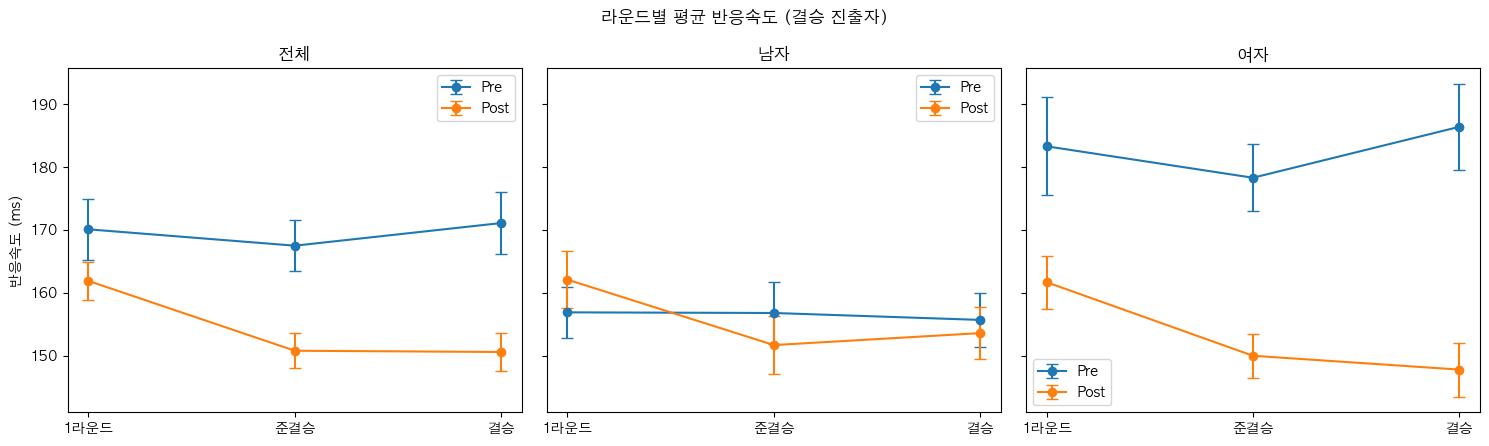

In [ ]:
trend_values_df = get_round_trend_values(finalist_complete_df)
display(trend_values_df)
plot_round_trend(trend_values_df)

## 3. 2 × 3 혼합 설계 분산분석
- 시기(Pre, Post; 집단 간) × 라운드(1라운드, 준결승, 결승; 집단 내)
- 핵심 효과는 **시기 × 라운드 상호작용**이다. 시기 주효과는 해석하지 않는다.
- 같은 선수라도 다른 대회는 다른 사례로 취급한다 (예: Bolt 2008, Bolt 2012).

### 3-1. 분석용 데이터

In [ ]:
def make_long_df(df):
    """선수(+연도) 한 명당 라운드 3줄인 긴 형식 데이터"""
    long_df = df[['ATHLETE', 'Year', 'Gender', 'Era', 'Round_Group', 'Rxn_ms']].copy()
    long_df['Subject'] = long_df['ATHLETE'] + '_' + long_df['Year'].astype(str)
    long_df['Round_Group'] = long_df['Round_Group'].astype(str)
    return long_df


long_df = make_long_df(finalist_complete_df)

print("[선수당 라운드 수: 모두 3이어야 함]")
display(long_df.groupby('Subject').size().value_counts())

# 연구의 한계 확인용: 두 시기에 모두 들어간 선수
both_eras = long_df.groupby('ATHLETE')['Era'].nunique()
print(f"\n[두 시기 모두 포함된 선수] {(both_eras > 1).sum()}명")
print(both_eras[both_eras > 1].index.to_list())

[선수당 라운드 수 확인 - 모두 3이어야 함]


3    61
Name: count, dtype: int64


[두 시기 모두 포함된 선수] 7명
['Asafa POWELL', 'Churandy MARTINA', 'Justin GATLIN', 'Richard THOMPSON', 'Shelly-Ann FRASER-PRYCE', 'Usain BOLT', 'Veronica CAMPBELL-BROWN']


### 3-2. 가정 확인 (정규성, 분산 동질성)
- 구형성(Mauchly) 결과는 3-3 분산분석 표에 함께 나온다.

In [ ]:
def check_anova_assumptions(long_df):
    """정규성(시기 x 라운드 셀별 Shapiro-Wilk), 분산 동질성(라운드별 Pre vs Post Levene)"""
    norm_rows, levene_rows = [], []
    for g_name, g in GENDER_GROUPS:
        d = long_df if g is None else long_df[long_df['Gender'] == g]
        for r in ROUND_ORDER:
            dr = d[d['Round_Group'] == r]
            for era in ERA_ORDER:
                x = dr.loc[dr['Era'] == era, 'Rxn_ms']
                w, p = stats.shapiro(x)
                norm_rows.append({'성별': g_name, '라운드': ROUND_LABEL[r], '시기': era, 'N': len(x),
                                  'W': round(w, 3), 'p-val': format_p_value(p),
                                  '정규성': '만족' if p >= ALPHA else '위배'})
            lev_w, lev_p = stats.levene(dr.loc[dr['Era'] == 'Pre', 'Rxn_ms'],
                                        dr.loc[dr['Era'] == 'Post', 'Rxn_ms'], center='mean')
            levene_rows.append({'성별': g_name, '라운드': ROUND_LABEL[r],
                                'Levene W': round(lev_w, 3), 'p-val': format_p_value(lev_p),
                                '분산 동질성': '만족' if lev_p >= ALPHA else '위배'})
    return pd.DataFrame(norm_rows), pd.DataFrame(levene_rows)


anova_norm_df, anova_levene_df = check_anova_assumptions(long_df)
print("[정규성: Shapiro-Wilk]")
display(anova_norm_df)
print("\n[분산 동질성: Levene]")
display(anova_levene_df)

====== [2-2] 정규성 (Shapiro-Wilk) ======


,성별,라운드,시기,N,W,p-val,정규성
0,전체,1라운드,Pre,30,0.901,0.0091,위배
1,전체,1라운드,Post,31,0.989,0.9848,만족
2,전체,준결승,Pre,30,0.974,0.6518,만족
3,전체,준결승,Post,31,0.980,0.8051,만족
4,전체,결승,Pre,30,0.942,0.1060,만족
5,전체,결승,Post,31,0.975,0.6573,만족
6,남자,1라운드,Pre,15,0.925,0.2320,만족
7,남자,1라운드,Post,15,0.973,0.9006,만족
8,남자,준결승,Pre,15,0.971,0.8765,만족
9,남자,준결승,Post,15,0.923,0.2133,만족



====== [2-2] 분산 동질성 (Levene) ======


,성별,라운드,Levene W,p-val,분산 동질성
0,전체,1라운드,2.640,0.1096,만족
1,전체,준결승,2.740,0.1032,만족
2,전체,결승,4.454,0.0391,위배
3,남자,1라운드,0.127,0.7239,만족
4,남자,준결승,0.123,0.7286,만족
5,남자,결승,0.181,0.6734,만족
6,여자,1라운드,6.805,0.0142,위배
7,여자,준결승,3.401,0.0754,만족
8,여자,결승,2.398,0.1323,만족


### 3-3. 분산분석
- `Era` = 시기 주효과 (해석 안 함), `Round_Group` = 라운드 주효과, `Interaction` = 시기 × 라운드 (**핵심**)
- 구형성이 위배되면(`sphericity` = False) `p_GG_corr`(Greenhouse-Geisser 보정) 값을 보고한다.

In [ ]:
def run_mixed_anova(long_df):
    """성별 집단마다 2 x 3 혼합 설계 분산분석"""
    results = []
    for g_name, g in GENDER_GROUPS:
        d = long_df if g is None else long_df[long_df['Gender'] == g]
        aov = pg.mixed_anova(data=d, dv='Rxn_ms', within='Round_Group', between='Era',
                             subject='Subject', correction=True, effsize='np2')
        aov.insert(0, '성별', g_name)
        results.append(aov)
    return pd.concat(results, ignore_index=True).round(3)


anova_df = run_mixed_anova(long_df)
display(anova_df)

====== [2-3] 2 x 3 혼합 설계 분산분석 ======


,성별,Source,SS,DF1,DF2,MS,F,p_unc,p_GG_corr,np2,eps,sphericity,W_spher,p_spher
0,전체,Era,10479.214,1,59,10479.214,10.886,0.002,NaN,0.156,NaN,NaN,NaN,NaN
1,전체,Round_Group,1578.142,2,118,789.071,3.959,0.022,0.026,0.063,0.969,True,0.968,0.381
2,전체,Interaction,1197.043,2,118,598.521,3.003,0.053,NaN,0.048,NaN,NaN,NaN,NaN
3,남자,Era,10.678,1,28,10.678,0.018,0.894,NaN,0.001,NaN,NaN,NaN,NaN
4,남자,Round_Group,506.156,2,56,253.078,1.752,0.183,0.188,0.059,0.981,True,0.981,0.760
5,남자,Interaction,423.889,2,56,211.944,1.467,0.239,NaN,0.050,NaN,NaN,NaN,NaN
6,여자,Era,20212.258,1,29,20212.258,23.768,0.000,NaN,0.450,NaN,NaN,NaN,NaN
7,여자,Round_Group,1158.215,2,58,579.108,2.241,0.116,0.127,0.072,0.957,True,0.955,0.511
8,여자,Interaction,1128.710,2,58,564.355,2.184,0.122,NaN,0.070,NaN,NaN,NaN,NaN


### 3-4. 사후 분석: 시기별 라운드 비교 (대응표본 t검정, Bonferroni 보정)

In [ ]:
def run_posthoc(long_df):
    """시기마다 라운드끼리 비교"""
    results = []
    for g_name, g in GENDER_GROUPS:
        d = long_df if g is None else long_df[long_df['Gender'] == g]
        post = pg.pairwise_tests(data=d, dv='Rxn_ms', within='Round_Group', between='Era',
                                 subject='Subject', padjust='bonf', within_first=False, effsize='cohen')
        post = post[post['Contrast'].str.contains(r'\*')].copy()   # 시기 x 라운드 행만
        post.insert(0, '성별', g_name)
        results.append(post)
    out = pd.concat(results, ignore_index=True)
    out[['A', 'B']] = out[['A', 'B']].replace(ROUND_LABEL)
    return out.round(3)


posthoc_df = run_posthoc(long_df)
display(posthoc_df)

====== [2-4] 사후 분석: 시기별 라운드 비교 ======


,성별,Contrast,Era,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,전체,Era * Round_Group,Post,결승,1라운드,True,True,-4.683,30.0,two-sided,0.000,0.000,bonf,428.822,-0.675
1,전체,Era * Round_Group,Post,결승,준결승,True,True,-0.071,30.0,two-sided,0.944,1.000,bonf,0.192,-0.012
2,전체,Era * Round_Group,Post,1라운드,준결승,True,True,4.076,30.0,two-sided,0.000,0.002,bonf,93.125,0.682
3,전체,Era * Round_Group,Pre,결승,1라운드,True,True,0.195,29.0,two-sided,0.847,1.000,bonf,0.198,0.036
4,전체,Era * Round_Group,Pre,결승,준결승,True,True,0.811,29.0,two-sided,0.424,1.000,bonf,0.263,0.144
5,전체,Era * Round_Group,Pre,1라운드,준결승,True,True,0.651,29.0,two-sided,0.520,1.000,bonf,0.236,0.103
6,남자,Era * Round_Group,Post,결승,1라운드,True,True,-2.481,14.0,two-sided,0.026,0.159,bonf,2.536,-0.505
7,남자,Era * Round_Group,Post,결승,준결승,True,True,0.692,14.0,two-sided,0.500,1.000,bonf,0.323,0.114
8,남자,Era * Round_Group,Post,1라운드,준결승,True,True,2.709,14.0,two-sided,0.017,0.102,bonf,3.619,0.589
9,남자,Era * Round_Group,Pre,결승,1라운드,True,True,-0.198,14.0,two-sided,0.846,1.000,bonf,0.267,-0.071


### 3-5. 상호작용 대비
- 상호작용을 두 라운드씩 나눈 대비로, 선수별 변화 폭을 Pre와 Post로 비교한 것과 같다.
- 분산분석과 같은 가정(등분산 t검정)을 쓴다: F(1, df) = t², ηp² = t² / (t² + df)
- Cohen's d가 양수이면 Post에서 더 많이 빨라졌다는 뜻이다.

In [ ]:
def run_interaction_contrasts(change_df):
    """구간별 변화 폭을 Pre vs Post로 비교 (등분산 t검정)"""
    rows = []
    for col, (start, end, _) in CHANGE_COLS.items():
        for g_name, g in GENDER_GROUPS:
            d = change_df if g is None else change_df[change_df['Gender'] == g]
            pre, post = d.loc[d['Era'] == 'Pre', col], d.loc[d['Era'] == 'Post', col]
            t, p = stats.ttest_ind(pre, post, equal_var=True)
            df_ = len(pre) + len(post) - 2
            rows.append({'대비': f"시기 x ({ROUND_LABEL[start]} vs {ROUND_LABEL[end]})", '성별': g_name,
                         'Pre 변화(ms)': round(pre.mean(), 1), 'Post 변화(ms)': round(post.mean(), 1),
                         '차이(ms)': round(post.mean() - pre.mean(), 1),
                         'F(1, df)': round(t ** 2, 2), 'df': df_, 'p-val': format_p_value(p),
                         'ηp²': round(t ** 2 / (t ** 2 + df_), 3), "Cohen's d": round(cohens_d(pre, post), 2)})
    return pd.DataFrame(rows)


contrast_df = run_interaction_contrasts(change_df)
display(contrast_df)

====== [2-5] 상호작용 대비 (변화 폭 비교) ======


,대비,성별,Pre 변화(ms),Post 변화(ms),차이(ms),"F(1, df)",df,p-val,ηp²,Cohen's d
0,시기 x (1라운드 vs 결승),전체,1.0,-11.3,-12.2,5.04,59,0.0286,0.079,0.57
1,시기 x (1라운드 vs 결승),남자,-1.1,-8.5,-7.3,1.22,28,0.2797,0.042,0.40
2,시기 x (1라운드 vs 결승),여자,3.1,-13.9,-16.9,3.78,29,0.0615,0.115,0.70
3,시기 x (1라운드 vs 준결승),전체,-2.6,-11.1,-8.5,3.19,59,0.0794,0.051,0.46
4,시기 x (1라운드 vs 준결승),남자,-0.1,-10.4,-10.3,3.12,28,0.0881,0.100,0.65
5,시기 x (1라운드 vs 준결승),여자,-5.1,-11.7,-6.6,0.76,29,0.3917,0.025,0.31
6,시기 x (준결승 vs 결승),전체,3.5,-0.2,-3.7,0.53,59,0.4686,0.009,0.19
7,시기 x (준결승 vs 결승),남자,-1.1,1.9,3.0,0.24,28,0.6262,0.009,-0.18
8,시기 x (준결승 vs 결승),여자,8.1,-2.2,-10.3,1.60,29,0.2155,0.052,0.46


## 4. 시기마다 라운드 간 변화가 있었는가
- 전체 변화 = 결승 − 1라운드 (주 지표), 앞 구간 = 준결승 − 1라운드, 뒤 구간 = 결승 − 준결승
- 변화 폭이 0과 다른지 검정: 정규성 만족 → 대응표본 t검정, 위배 → 윌콕슨 부호순위 검정
- 효과크기가 음수이면 뒤 라운드에서 빨라졌다는 뜻이다.

In [ ]:
print("[선수별 변화 폭 평균(ms)]")
display(change_df.groupby(['Era', 'Gender'])[list(CHANGE_COLS)].mean().round(1).reindex(ERA_ORDER, level=0))

[선수별 변화 폭 평균(ms) - 음수 = 뒤 라운드에서 빨라짐]


d_total  d_front  d_back
Era  Gender                          
Pre  F           3.1     -5.1     8.1
     M          -1.1     -0.1    -1.1
Post F         -13.9    -11.7    -2.2
     M          -8.5    -10.4     1.9

In [ ]:
def test_change_vs_zero(change_df, cols=tuple(CHANGE_COLS)):
    """시기 x 성별마다 변화 폭이 0과 다른지 검정"""
    rows = []
    for col in cols:
        col_label = CHANGE_COLS[col][2]
        for era in ERA_ORDER:
            for g_name, g in GENDER_GROUPS:
                d = change_df[change_df['Era'] == era]
                if g:
                    d = d[d['Gender'] == g]
                x = d[col].dropna()
                method, stat, p_val, effect_name, effect = test_vs_zero(x)
                rows.append({
                    '구간': col_label, '시기': era, '성별': g_name, 'N': len(x),
                    '평균 변화(ms)': round(x.mean(), 1), '중앙값(ms)': round(x.median(), 1),
                    '검정 방법': method, '통계량': round(stat, 3), 'p-val': format_p_value(p_val),
                    '유의성': '유의함' if p_val < ALPHA else '유의하지 않음',
                    '효과크기 종류': effect_name, '효과크기': round(effect, 2),
                    '방향': '뒤 라운드에서 빨라짐' if x.mean() < 0 else '뒤 라운드에서 느려짐',
                })
    return pd.DataFrame(rows)


zero_test_df = test_change_vs_zero(change_df)
display(zero_test_df)

====== [4단계] 시기별 변화 폭이 0과 다른가? (음수 효과크기 = 빨라짐) ======


,구간,시기,성별,N,평균 변화(ms),중앙값(ms),검정 방법,통계량,p-val,유의성,효과크기 종류,효과크기,방향
0,전체 변화 (결승 − 1라운드),Pre,전체,30,1.0,-1.5,대응표본 t검정,0.195,0.8465,유의하지 않음,Cohen's dz,0.04,뒤 라운드에서 느려짐
1,전체 변화 (결승 − 1라운드),Pre,남자,15,-1.1,-2.0,대응표본 t검정,-0.198,0.8455,유의하지 않음,Cohen's dz,-0.05,뒤 라운드에서 빨라짐
2,전체 변화 (결승 − 1라운드),Pre,여자,15,3.1,-1.0,윌콕슨 부호순위,57.500,0.8870,유의하지 않음,순위 상관 r,-0.04,뒤 라운드에서 느려짐
3,전체 변화 (결승 − 1라운드),Post,전체,31,-11.3,-9.0,대응표본 t검정,-4.683,< 0.0001,유의함,Cohen's dz,-0.84,뒤 라운드에서 빨라짐
4,전체 변화 (결승 − 1라운드),Post,남자,15,-8.5,-8.0,대응표본 t검정,-2.481,0.0264,유의함,Cohen's dz,-0.64,뒤 라운드에서 빨라짐
5,전체 변화 (결승 − 1라운드),Post,여자,16,-13.9,-13.0,대응표본 t검정,-4.134,0.0009,유의함,Cohen's dz,-1.03,뒤 라운드에서 빨라짐
6,앞 구간 변화 (준결승 − 1라운드),Pre,전체,30,-2.6,1.0,대응표본 t검정,-0.651,0.5204,유의하지 않음,Cohen's dz,-0.12,뒤 라운드에서 빨라짐
7,앞 구간 변화 (준결승 − 1라운드),Pre,남자,15,-0.1,5.0,윌콕슨 부호순위,45.000,0.3938,유의하지 않음,순위 상관 r,0.25,뒤 라운드에서 빨라짐
8,앞 구간 변화 (준결승 − 1라운드),Pre,여자,15,-5.1,-9.0,대응표본 t검정,-0.763,0.4583,유의하지 않음,Cohen's dz,-0.20,뒤 라운드에서 빨라짐
9,앞 구간 변화 (준결승 − 1라운드),Post,전체,31,-11.1,-13.0,대응표본 t검정,-4.076,0.0003,유의함,Cohen's dz,-0.73,뒤 라운드에서 빨라짐


## 5. 변화 폭의 규정 전후 비교 (주 분석)
- 3-5와 같은 질문을 분산 차이와 정규성 위배를 고려한 검정으로 확인한다.
- 두 집단 모두 정규성 만족 → Welch t검정, 하나라도 위배 → Mann-Whitney U 검정
- 효과크기: Cohen's d = (Pre − Post) / 합동 표준편차, rank-biserial r = 2U / (n1·n2) − 1
  - 두 값 모두 **양수이면 Post에서 더 많이 빨라졌다**는 뜻이다.

In [ ]:
def compare_pre_post(change_df, col, label=''):
    """변화 폭(col)을 Pre vs Post로 비교 (전체/남자/여자)"""
    rows = []
    for g_name, g in GENDER_GROUPS:
        d = change_df if g is None else change_df[change_df['Gender'] == g]
        pre, post = d.loc[d['Era'] == 'Pre', col].dropna(), d.loc[d['Era'] == 'Post', col].dropna()

        if stats.shapiro(pre).pvalue >= ALPHA and stats.shapiro(post).pvalue >= ALPHA:
            stat, p_val = stats.ttest_ind(pre, post, equal_var=False)
            method, effect_name, effect = "Welch's t-test", "Cohen's d", cohens_d(pre, post)
        else:
            stat, p_val = stats.mannwhitneyu(pre, post, alternative='two-sided')
            method, effect_name, effect = 'Mann-Whitney U', 'rank-biserial r', 2 * stat / (len(pre) * len(post)) - 1

        rows.append({
            '분석': label, '성별': g_name, 'N (Pre/Post)': f"{len(pre)}/{len(post)}",
            'Pre 평균(ms)': round(pre.mean(), 1), 'Post 평균(ms)': round(post.mean(), 1),
            'Pre 중앙값': round(pre.median(), 1), 'Post 중앙값': round(post.median(), 1),
            '검정 방법': method, '통계량': round(stat, 3), 'p-val': format_p_value(p_val),
            '유의성': '유의함' if p_val < ALPHA else '유의하지 않음',
            '효과크기 종류': effect_name, '효과크기': round(effect, 2),
            '방향': 'Post에서 더 많이 빨라짐' if post.mean() < pre.mean() else 'Pre에서 더 많이 빨라짐',
        })
    return pd.DataFrame(rows)

### 5-1. 변화 폭 정규성 확인

In [ ]:
def check_change_normality(change_df, cols=tuple(CHANGE_COLS)):
    """구간 x 성별 x 시기별 변화 폭 정규성과, 그에 따라 5단계에서 쓰는 검정 방법"""
    rows = []
    for col in cols:
        col_label = CHANGE_COLS[col][2]
        for g_name, g in GENDER_GROUPS:
            d = change_df if g is None else change_df[change_df['Gender'] == g]
            for era in ERA_ORDER:
                x = d.loc[d['Era'] == era, col].dropna()
                w_stat, p_val = stats.shapiro(x)
                rows.append({'구간': col_label, '성별': g_name, '시기': era, 'N': len(x),
                             'W 통계량': round(w_stat, 4), 'p-val': format_p_value(p_val),
                             '정규성 판정': '정규성 만족' if p_val >= ALPHA else '정규성 위배'})
    result = pd.DataFrame(rows)
    both_ok = result.groupby(['구간', '성별'], sort=False)['정규성 판정'].transform(lambda s: (s == '정규성 만족').all())
    result['검정 방법'] = np.where(both_ok, "Welch's t-test", 'Mann-Whitney U')
    return result


normality_change_df = check_change_normality(change_df)
display(normality_change_df)

print("\n[정규성 위배 집단]")
display(normality_change_df[normality_change_df['정규성 판정'] == '정규성 위배'])

====== 변화 폭 정규성 검정 (Shapiro-Wilk) ======


,구간,성별,시기,N,W 통계량,p-val,정규성 판정,5단계 검정 방법
0,전체 변화 (결승 − 1라운드),전체,Pre,30,0.9531,0.2042,정규성 만족,Welch's t-test
1,전체 변화 (결승 − 1라운드),전체,Post,31,0.9690,0.4931,정규성 만족,Welch's t-test
2,전체 변화 (결승 − 1라운드),남자,Pre,15,0.9606,0.7033,정규성 만족,Welch's t-test
3,전체 변화 (결승 − 1라운드),남자,Post,15,0.9475,0.4859,정규성 만족,Welch's t-test
4,전체 변화 (결승 − 1라운드),여자,Pre,15,0.8785,0.0450,정규성 위배,Mann-Whitney U
5,전체 변화 (결승 − 1라운드),여자,Post,16,0.9643,0.7403,정규성 만족,Mann-Whitney U
6,앞 구간 변화 (준결승 − 1라운드),전체,Pre,30,0.9649,0.4111,정규성 만족,Welch's t-test
7,앞 구간 변화 (준결승 − 1라운드),전체,Post,31,0.9724,0.5875,정규성 만족,Welch's t-test
8,앞 구간 변화 (준결승 − 1라운드),남자,Pre,15,0.8059,0.0044,정규성 위배,Mann-Whitney U
9,앞 구간 변화 (준결승 − 1라운드),남자,Post,15,0.9859,0.9949,정규성 만족,Mann-Whitney U



====== 정규성 위배 그룹만 ======


,구간,성별,시기,N,W 통계량,p-val,정규성 판정,5단계 검정 방법
4,전체 변화 (결승 − 1라운드),여자,Pre,15,0.8785,0.0450,정규성 위배,Mann-Whitney U
8,앞 구간 변화 (준결승 − 1라운드),남자,Pre,15,0.8059,0.0044,정규성 위배,Mann-Whitney U
13,뒤 구간 변화 (결승 − 준결승),전체,Post,31,0.9171,0.0198,정규성 위배,Mann-Whitney U


### 5-2. 전체 변화 (결승 − 1라운드)

In [ ]:
total_result_df = compare_pre_post(change_df, 'd_total', label='결승 진출자: 전체 변화')
display(total_result_df)

====== [5-2단계] 전체 변화 폭 (결승 − 1라운드) Pre vs Post ======


,분석,성별,N (Pre/Post),Pre 평균(ms),Post 평균(ms),Pre 중앙값,Post 중앙값,검정 방법,통계량,p-val,유의성,효과크기 종류,효과크기,방향
0,결승 진출자: 전체 변화,전체,30/31,1.0,-11.3,-1.5,-9.0,Welch's t-test,2.222,0.0317,유의함,Cohen's d,0.57,Post에서 더 많이 빨라짐
1,결승 진출자: 전체 변화,남자,15/15,-1.1,-8.5,-2.0,-8.0,Welch's t-test,1.102,0.2818,유의하지 않음,Cohen's d,0.40,Post에서 더 많이 빨라짐
2,결승 진출자: 전체 변화,여자,15/16,3.1,-13.9,-1.0,-13.0,Mann-Whitney U,172.000,0.0417,유의함,rank-biserial r,0.43,Post에서 더 많이 빨라짐


### 5-3. 구간별 변화 (앞 구간, 뒤 구간)

In [ ]:
front_result_df = compare_pre_post(change_df, 'd_front', label='결승 진출자: 앞 구간')
back_result_df = compare_pre_post(change_df, 'd_back', label='결승 진출자: 뒤 구간')

print("[앞 구간: 준결승 − 1라운드]")
display(front_result_df)
print("\n[뒤 구간: 결승 − 준결승]")
display(back_result_df)

====== [5-3단계] 앞 구간 (준결승 − 1라운드) ======


,분석,성별,N (Pre/Post),Pre 평균(ms),Post 평균(ms),Pre 중앙값,Post 중앙값,검정 방법,통계량,p-val,유의성,효과크기 종류,효과크기,방향
0,결승 진출자: 앞 구간,전체,30/31,-2.6,-11.1,1.0,-13.0,Welch's t-test,1.775,0.0819,유의하지 않음,Cohen's d,0.46,Post에서 더 많이 빨라짐
1,결승 진출자: 앞 구간,남자,15/15,-0.1,-10.4,5.0,-11.0,Mann-Whitney U,165.500,0.0294,유의함,rank-biserial r,0.47,Post에서 더 많이 빨라짐
2,결승 진출자: 앞 구간,여자,15/16,-5.1,-11.7,-9.0,-16.5,Welch's t-test,0.857,0.4005,유의하지 않음,Cohen's d,0.31,Post에서 더 많이 빨라짐



====== [5-3단계] 뒤 구간 (결승 − 준결승) ======


,분석,성별,N (Pre/Post),Pre 평균(ms),Post 평균(ms),Pre 중앙값,Post 중앙값,검정 방법,통계량,p-val,유의성,효과크기 종류,효과크기,방향
0,결승 진출자: 뒤 구간,전체,30/31,3.5,-0.2,4.0,1.0,Mann-Whitney U,495.000,0.6703,유의하지 않음,rank-biserial r,0.06,Post에서 더 많이 빨라짐
1,결승 진출자: 뒤 구간,남자,15/15,-1.1,1.9,-3.0,2.0,Welch's t-test,-0.492,0.6275,유의하지 않음,Cohen's d,-0.18,Pre에서 더 많이 빨라짐
2,결승 진출자: 뒤 구간,여자,15/16,8.1,-2.2,5.0,-1.0,Welch's t-test,1.252,0.2221,유의하지 않음,Cohen's d,0.46,Post에서 더 많이 빨라짐


### 5-4. 준결승 진출자 전체의 앞 구간 변화
- 결승 진출자로 좁히지 않고, 1라운드와 준결승 기록이 모두 있는 선수 전체로 앞 구간을 다시 비교한다.

In [ ]:
semi_change_df = build_change_table(race_df, required_rounds=['R1', 'Semi'])

print("[1라운드·준결승 반응속도가 모두 있는 선수 수]")
display(semi_change_df.groupby(['Era', 'Gender']).size().unstack().reindex(ERA_ORDER))

semi_result_df = compare_pre_post(semi_change_df, 'd_front', label='준결승 진출자: 앞 구간')
print("\n[앞 구간: 준결승 진출자 전체]")
display(semi_result_df)

[1라운드·준결승 반응속도가 모두 있는 선수 수]


Gender,F,M
Era,,
Pre,30,31
Post,46,44



====== [6단계] 앞 구간 (준결승 − 1라운드), 준결승 진출자 전체 ======


,분석,성별,N (Pre/Post),Pre 평균(ms),Post 평균(ms),Pre 중앙값,Post 중앙값,검정 방법,통계량,p-val,유의성,효과크기 종류,효과크기,방향
0,준결승 진출자: 앞 구간,전체,61/90,-4.6,-5.8,-4.0,-4.5,Welch's t-test,0.402,0.6887,유의하지 않음,Cohen's d,0.07,Post에서 더 많이 빨라짐
1,준결승 진출자: 앞 구간,남자,31/44,-1.5,-7.7,1.0,-8.5,Welch's t-test,1.868,0.0669,유의하지 않음,Cohen's d,0.45,Post에서 더 많이 빨라짐
2,준결승 진출자: 앞 구간,여자,30/46,-7.8,-4.0,-13.0,0.0,Welch's t-test,-0.727,0.4714,유의하지 않음,Cohen's d,-0.19,Pre에서 더 많이 빨라짐


### 5-5. 변화 폭의 흩어진 정도 비교 (Levene 검정)

In [ ]:
pre = change_df.loc[change_df['Era'] == 'Pre', 'd_total']
post = change_df.loc[change_df['Era'] == 'Post', 'd_total']
w, p = stats.levene(pre, post, center='median')
print(f"Pre SD = {pre.std():.1f}, Post SD = {post.std():.1f}, Levene W = {w:.2f}, p = {format_p_value(p)}")

Pre SD = 27.1, Post SD = 13.4, Levene W = 5.11, p = 0.0276


## 6. 대회별 확인 (민감도 분석)
- 결과가 특정 대회 하나 때문에 나온 것이 아닌지 대회별로 나누어 확인한다.

### 6-1. 대회별 라운드 간 변화

====== [7-3-1] 연도 x 라운드 평균 반응속도 (ms) ======


,시기,1라운드,준결승,결승
Year,,,,
2004,Pre,175.0,170.3,178.4
2008,Pre,165.8,165.1,164.7
2012,Post,168.5,155.1,159.8
2016,Post,155.7,146.8,142.0



====== [7-3-2] 연도별 변화 폭이 0과 다른가 (음수 = 뒤 라운드에서 빨라짐) ======


,구간,연도,시기,n,M ± SD (ms),검정,p,효과크기
0,1라운드–결승,2004,Pre,14,3.4 ± 15.8,대응표본 t,0.4407,dz = 0.21
1,,2008,Pre,16,-1.1 ± 34.6,대응표본 t,0.8981,dz = -0.03
2,,2012,Post,15,-8.7 ± 12.8,대응표본 t,0.0202,dz = -0.68
3,,2016,Post,16,-13.7 ± 13.9,대응표본 t,0.0013,dz = -0.99
4,1라운드–준결승,2004,Pre,14,-4.7 ± 19.5,대응표본 t,0.3816,dz = -0.24
5,,2008,Pre,16,-0.7 ± 23.8,대응표본 t,0.9095,dz = -0.03
6,,2012,Post,15,-13.4 ± 12.3,대응표본 t,0.0008,dz = -1.09
7,,2016,Post,16,-8.9 ± 17.5,대응표본 t,0.0604,dz = -0.51
8,준결승–결승,2004,Pre,14,8.1 ± 14.4,대응표본 t,0.0563,dz = 0.56
9,,2008,Pre,16,-0.4 ± 29.7,대응표본 t,0.9539,dz = -0.01



====== [7-3-3] 같은 시기 안의 두 대회 비교 (앞 대회 vs 뒤 대회) ======

--- 전체 변화 (결승 − 1라운드) ---


,시기,비교,n,앞 대회 M ± SD,뒤 대회 M ± SD,검정,p,효과크기
0,Pre,2004 vs 2008,14/16,3.4 ± 15.8,-1.1 ± 34.6,Welch t,0.6458,d = 0.16
1,Post,2012 vs 2016,15/16,-8.7 ± 12.8,-13.7 ± 13.9,Welch t,0.3033,d = 0.38



--- 앞 구간 변화 (준결승 − 1라운드) ---


,시기,비교,n,앞 대회 M ± SD,뒤 대회 M ± SD,검정,p,효과크기
0,Pre,2004 vs 2008,14/16,-4.7 ± 19.5,-0.7 ± 23.8,Welch t,0.6144,d = -0.18
1,Post,2012 vs 2016,15/16,-13.4 ± 12.3,-8.9 ± 17.5,Welch t,0.4094,d = -0.30



--- 뒤 구간 변화 (결승 − 준결승) ---


,시기,비교,n,앞 대회 M ± SD,뒤 대회 M ± SD,검정,p,효과크기
0,Pre,2004 vs 2008,14/16,8.1 ± 14.4,-0.4 ± 29.7,Welch t,0.3205,d = 0.36
1,Post,2012 vs 2016,15/16,4.7 ± 12.3,-4.8 ± 16.7,Mann-Whitney U,0.0928,r = 0.36


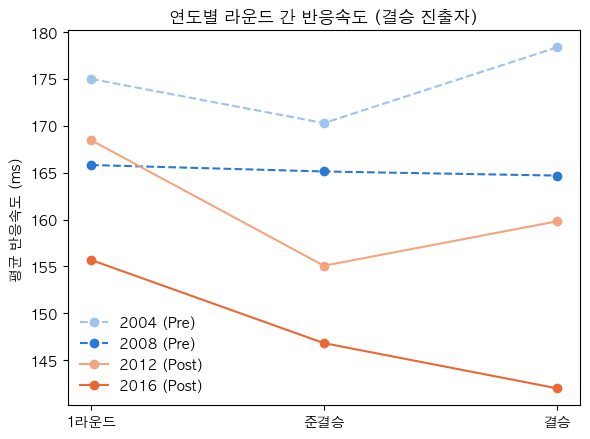

In [ ]:
def get_year_round_means(df):
    """연도 x 라운드별 평균 반응속도 (남녀 합산)"""
    table = df.groupby(['Year', 'Round_Group'], observed=False)['Rxn_ms'].mean().round(1).unstack()
    table.columns = [ROUND_LABEL[c] for c in table.columns]
    table.insert(0, '시기', table.index.map(ERA_BY_YEAR))
    return table


def test_change_by_year(change_df, cols=tuple(CHANGE_COLS)):
    """연도마다 변화 폭이 0과 다른지 (4단계와 같은 방법)"""
    rows = []
    for col in cols:
        start, end, _ = CHANGE_COLS[col]
        for year in TARGET_YEARS:
            x = change_df.loc[change_df['Year'] == year, col].dropna()
            method, _, p, effect_name, effect = test_vs_zero(x)
            es = f"dz = {effect:.2f}" if effect_name == "Cohen's dz" else f"r = {effect:.2f}"
            rows.append({'구간': f"{ROUND_LABEL[start]}–{ROUND_LABEL[end]}", '연도': year,
                         '시기': ERA_BY_YEAR[year], 'n': len(x),
                         'M ± SD (ms)': f"{x.mean():.1f} ± {x.std(ddof=1):.1f}",
                         '검정': method, 'p': format_p_value(p), '효과크기': es})
    table = pd.DataFrame(rows)
    table.loc[table['구간'].duplicated(), '구간'] = ''
    return table


def compare_years_within_era(change_df, col='d_total'):
    """같은 시기 안의 두 대회 비교 (2004 vs 2008, 2012 vs 2016)
    차이가 없으면 두 대회를 한 시기로 묶어도 된다는 근거가 됨"""
    rows = []
    for era, (y1, y2) in [('Pre', (2004, 2008)), ('Post', (2012, 2016))]:
        a = change_df.loc[change_df['Year'] == y1, col]
        b = change_df.loc[change_df['Year'] == y2, col]
        if stats.shapiro(a).pvalue >= ALPHA and stats.shapiro(b).pvalue >= ALPHA:
            _, p = stats.ttest_ind(a, b, equal_var=False)
            test, es = 'Welch t', f"d = {cohens_d(a, b):.2f}"
        else:
            u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            test, es = 'Mann-Whitney U', f"r = {2 * u / (len(a) * len(b)) - 1:.2f}"
        rows.append({'시기': era, '비교': f"{y1} vs {y2}", 'n': f"{len(a)}/{len(b)}",
                     '앞 대회 M ± SD': f"{a.mean():.1f} ± {a.std(ddof=1):.1f}",
                     '뒤 대회 M ± SD': f"{b.mean():.1f} ± {b.std(ddof=1):.1f}",
                     '검정': test, 'p': format_p_value(p), '효과크기': es})
    return pd.DataFrame(rows)


def plot_year_round_trend(df):
    """연도별 라운드 평균 흐름 (Pre = 파란 점선, Post = 주황 실선)"""
    colors = {2004: '#9DC3F0', 2008: '#2A78D6', 2012: '#F3A57F', 2016: '#EB6834'}
    means = df.groupby(['Year', 'Round_Group'], observed=False)['Rxn_ms'].mean().unstack()
    fig, ax = plt.subplots(figsize=(6, 4.5))
    x = range(len(ROUND_ORDER))
    for year in TARGET_YEARS:
        ax.plot(x, means.loc[year, ROUND_ORDER], marker='o', color=colors[year],
                linestyle='-' if ERA_BY_YEAR[year] == 'Post' else '--', label=f"{year} ({ERA_BY_YEAR[year]})")
    ax.set_xticks(list(x))
    ax.set_xticklabels([ROUND_LABEL[r] for r in ROUND_ORDER])
    ax.set_ylabel('평균 반응속도 (ms)')
    ax.set_title('연도별 라운드 간 반응속도 (결승 진출자)')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


print("[연도 x 라운드 평균 반응속도 (ms)]")
display(get_year_round_means(finalist_complete_df))

print("\n[연도별 변화 폭이 0과 다른가]")
display(test_change_by_year(change_df))

print("\n[같은 시기 안의 두 대회 비교]")
for col in CHANGE_COLS:
    print(f"\n--- {CHANGE_COLS[col][2]} ---")
    display(compare_years_within_era(change_df, col))

plot_year_round_trend(finalist_complete_df)

### 6-2. 대회별 신뢰구간, 대회 짝 비교, 대회 하나씩 빼기 (전체 변화 기준)
- A. 대회별 평균과 부트스트랩 95% 신뢰구간
- B. Pre 대회와 Post 대회를 하나씩 짝지어 비교 (4쌍)
- C. 대회 하나씩 빼고 주 분석(5-2) 다시 실시

In [ ]:
rng = np.random.default_rng(2026)
PRE_YEARS, POST_YEARS = [2004, 2008], [2012, 2016]


def bootstrap_ci(values, n=10000):
    """평균과 부트스트랩 95% 신뢰구간"""
    means = [rng.choice(values, len(values)).mean() for _ in range(n)]
    low, high = np.percentile(means, [2.5, 97.5])
    return values.mean(), low, high


# A. 대회별 평균과 95% 신뢰구간
rows_a = []
for year in TARGET_YEARS:
    v = change_df.loc[change_df['Year'] == year, 'd_total'].dropna().to_numpy()
    m, low, high = bootstrap_ci(v)
    rows_a.append({'대회': year, '시기': ERA_BY_YEAR[year], 'N': len(v),
                   '평균 변화 폭(ms)': round(m, 1), '95% CI': f"[{low:.1f}, {high:.1f}]",
                   'CI가 0 포함?': '포함' if low <= 0 <= high else '포함 안 함'})
print("[A. 대회별 1라운드 → 결승 변화 폭]")
display(pd.DataFrame(rows_a))

# B. Pre 대회 x Post 대회 짝 비교
rows_b = []
for pre_year in PRE_YEARS:
    for post_year in POST_YEARS:
        pre = change_df.loc[change_df['Year'] == pre_year, 'd_total'].dropna()
        post = change_df.loc[change_df['Year'] == post_year, 'd_total'].dropna()
        _, p = stats.ttest_ind(pre, post, equal_var=False)
        rows_b.append({'비교': f"{pre_year} vs {post_year}", 'N': f"{len(pre)}/{len(post)}",
                       'Pre 평균(ms)': round(pre.mean(), 1), 'Post 평균(ms)': round(post.mean(), 1),
                       '차이 (Post − Pre)': round(post.mean() - pre.mean(), 1),
                       'p-val': format_p_value(p), "Cohen's d": round(cohens_d(pre, post), 2),
                       '방향': 'Post에서 더 빨라짐' if post.mean() < pre.mean() else 'Pre에서 더 빨라짐'})
print("\n[B. Pre 대회 x Post 대회 짝 비교]")
display(pd.DataFrame(rows_b))

# C. 대회 하나씩 빼고 다시 분석
rows_c = []
for drop_year in TARGET_YEARS:
    d = change_df[change_df['Year'] != drop_year]
    pre = d.loc[d['Era'] == 'Pre', 'd_total'].dropna()
    post = d.loc[d['Era'] == 'Post', 'd_total'].dropna()
    _, p = stats.ttest_ind(pre, post, equal_var=False)
    rows_c.append({'뺀 대회': drop_year, 'N (Pre/Post)': f"{len(pre)}/{len(post)}",
                   '차이 (Post − Pre)': round(post.mean() - pre.mean(), 1),
                   'p-val': format_p_value(p), "Cohen's d": round(cohens_d(pre, post), 2)})
print("\n[C. 대회 하나씩 빼고 다시 분석]")
display(pd.DataFrame(rows_c))

====== [7-4-A] 대회별 1라운드→결승 변화 폭 (음수 = 결승에서 빨라짐) ======


,대회,시기,N,평균 변화 폭(ms),95% CI,CI가 0 포함?
0,2004,Pre,14,3.4,"[-4.4, 11.6]",포함
1,2008,Pre,16,-1.1,"[-16.7, 15.8]",포함
2,2012,Post,15,-8.7,"[-15.0, -2.7]",포함 안 함
3,2016,Post,16,-13.7,"[-20.2, -7.2]",포함 안 함



====== [7-4-B] Pre 대회 × Post 대회 짝지어 비교 ======


,비교,N,Pre 평균(ms),Post 평균(ms),차이 (Post − Pre),p-val,Cohen's d,방향
0,2004 vs 2012,14/15,3.4,-8.7,-12.0,0.0340,0.84,Post에서 더 빨라짐
1,2004 vs 2016,14/16,3.4,-13.7,-17.0,0.0044,1.15,Post에서 더 빨라짐
2,2008 vs 2012,16/15,-1.1,-8.7,-7.5,0.4250,0.29,Post에서 더 빨라짐
3,2008 vs 2016,16/16,-1.1,-13.7,-12.6,0.1925,0.48,Post에서 더 빨라짐



====== [7-4-C] 대회 하나씩 빼고 다시 분석 (원래 결과: 차이 −12.2ms, d = 0.57) ======


,뺀 대회,N (Pre/Post),차이 (Post − Pre),p-val,Cohen's d
0,2004,16/31,-10.1,0.2739,0.45
1,2008,14/31,-14.6,0.0065,1.03
2,2012,30/16,-14.7,0.0195,0.62
3,2016,30/15,-9.6,0.1129,0.41


### 6-3. 2008년 변화 폭의 표준편차가 큰 이유 확인

In [ ]:
y2008 = change_df[change_df['Year'] == 2008][['ATHLETE', 'Gender', 'R1', 'Semi', 'Final', 'd_total']].copy()
y2008['변화 폭 크기'] = y2008['d_total'].abs()

print("[2008] 선수별 라운드 반응속도와 변화 폭 (변화 폭이 큰 순서)")
display(y2008.sort_values('변화 폭 크기', ascending=False).round(1))

print("\n[2008] 성별 변화 폭")
display(y2008.groupby('Gender')['d_total'].agg(N='count', 평균='mean', 표준편차='std').round(1))

# 200 ms 이상 = 부정출발 뒤 다시 출발한 경기일 가능성
print("\n[2008] 한 라운드라도 반응속도가 200 ms 이상인 선수")
display(y2008[(y2008[['R1', 'Semi', 'Final']] >= 200).any(axis=1)].round(1))

trimmed = y2008.sort_values('변화 폭 크기').iloc[:-2]['d_total']
print(f"\n[2008] 표준편차: 전체 {y2008['d_total'].std():.1f} ms → 변화 폭이 가장 큰 2명 제외 {trimmed.std():.1f} ms")

[2008] 선수별 라운드 반응속도와 변화 폭 (변화 폭이 큰 순서)


,ATHLETE,Gender,R1,Semi,Final,d_total,변화 폭 크기
26,Kerron STEWART,F,156.0,202.0,232.0,76.0,76.0
36,Muna LEE,F,173.0,155.0,234.0,61.0,61.0
43,Shelly-Ann FRASER-PRYCE,F,249.0,217.0,190.0,-59.0,59.0
39,Richard THOMPSON,M,170.0,175.0,133.0,-37.0,37.0
57,Walter DIX,M,163.0,143.0,133.0,-30.0,30.0
31,Marc BURNS,M,174.0,124.0,145.0,-29.0,29.0
11,Churandy MARTINA,M,142.0,138.0,169.0,27.0,27.0
50,Torri EDWARDS,F,160.0,174.0,179.0,19.0,19.0
14,Darvis PATTON,M,159.0,149.0,142.0,-17.0,17.0
5,Asafa POWELL,M,149.0,161.0,134.0,-15.0,15.0



[2008] 성별 변화 폭 평균과 표준편차


,N,평균,표준편차
Gender,,,
F,8,11.2,42.3
M,8,-13.5,20.5



[2008] 한 라운드라도 반응속도가 200ms 이상인 선수


,ATHLETE,Gender,R1,Semi,Final,d_total,변화 폭 크기
26,Kerron STEWART,F,156.0,202.0,232.0,76.0,76.0
36,Muna LEE,F,173.0,155.0,234.0,61.0,61.0
43,Shelly-Ann FRASER-PRYCE,F,249.0,217.0,190.0,-59.0,59.0



[2008] 전체 표준편차: 34.6ms → 변화 폭이 가장 큰 2명 제외: 22.7ms


## 7. 결승 기록 비교
- 분석 대상 선수들의 결승 기록(초)을 규정 전후로 비교한다. 남녀 기록 차이가 크므로 성별로 따로 본다.
- 효과크기가 음수이면 규정 후 기록이 더 빠르다는 뜻이다.

In [ ]:
def compare_final_mark(df):
    """결승 기록(MARK_sec) 규정 전후 비교 (성별로)"""
    final = df[df['Round_Group'] == 'Final']
    rows = []
    for g_name, g in [('남자', 'M'), ('여자', 'F')]:
        d = final[final['Gender'] == g]
        pre = d.loc[d['Era'] == 'Pre', 'MARK_sec']
        post = d.loc[d['Era'] == 'Post', 'MARK_sec']
        if stats.shapiro(pre).pvalue >= ALPHA and stats.shapiro(post).pvalue >= ALPHA:
            t, p = stats.ttest_ind(post, pre, equal_var=False)
            test, es = f"Welch t = {t:.2f}", f"d = {cohens_d(post, pre):.2f}"
        else:
            u, p = stats.mannwhitneyu(pre, post, alternative='two-sided')
            test, es = f"Mann-Whitney U = {u:.1f}", f"r = {1 - 2 * u / (len(pre) * len(post)):.2f}"
        rows.append({'성별': g_name, 'n (전/후)': f"{len(pre)}/{len(post)}",
                     '규정 전 M ± SD (s)': f"{pre.mean():.3f} ± {pre.std(ddof=1):.3f}",
                     '규정 후 M ± SD (s)': f"{post.mean():.3f} ± {post.std(ddof=1):.3f}",
                     '규정 전 중앙값': f"{pre.median():.3f}", '규정 후 중앙값': f"{post.median():.3f}",
                     '차이 (후 − 전, s)': f"{post.mean() - pre.mean():+.3f}",
                     '검정': test, 'p': format_p_value(p), '효과크기': es})
    return pd.DataFrame(rows)


display(compare_final_mark(finalist_complete_df))

print("\n[연도별 결승 기록 평균 ± SD (s)]")
final_mark_df = finalist_complete_df[finalist_complete_df['Round_Group'] == 'Final']
display(final_mark_df.groupby(['Gender', 'Year'])['MARK_sec'].agg(n='count', 평균='mean', SD='std').round(3))

====== 결승 기록(MARK) 규정 전후 비교 (음수 = 규정 후 기록이 더 빠름) ======


,성별,n (전/후),규정 전 M ± SD (s),규정 후 M ± SD (s),규정 전 중앙값,규정 후 중앙값,"차이 (후 − 전, s)",검정,p,효과크기
0,남자,15/15,9.926 ± 0.096,10.033 ± 0.553,9.930,9.930,+0.107,Mann-Whitney U = 118.0,0.8355,r = -0.05
1,여자,15/16,11.046 ± 0.117,10.928 ± 0.247,11.050,10.875,-0.118,Mann-Whitney U = 200.5,0.0016,r = -0.67



[연도별 결승 기록 평균 ± SD (s)]


n      평균     SD
Gender Year                  
F      2004  7  11.046  0.098
       2008  8  11.046  0.138
       2012  8  10.879  0.098
       2016  8  10.978  0.340
M      2004  7   9.930  0.092
       2008  8   9.922  0.105
       2012  7  10.137  0.826
       2016  8   9.942  0.080

## 8. 결과 요약

In [ ]:
summary_cols = ['분석', '성별', 'N (Pre/Post)', 'Pre 평균(ms)', 'Post 평균(ms)', '검정 방법',
                'p-val', '유의성', '효과크기 종류', '효과크기', '방향']
all_results_df = pd.concat([total_result_df, front_result_df, back_result_df, semi_result_df],
                           ignore_index=True)[summary_cols]
display(all_results_df)

,분석,성별,N (Pre/Post),Pre 평균(ms),Post 평균(ms),검정 방법,p-val,유의성,효과크기 종류,효과크기,방향
0,결승 진출자: 전체 변화,전체,30/31,1.0,-11.3,Welch's t-test,0.0317,유의함,Cohen's d,0.57,Post에서 더 많이 빨라짐
1,결승 진출자: 전체 변화,남자,15/15,-1.1,-8.5,Welch's t-test,0.2818,유의하지 않음,Cohen's d,0.40,Post에서 더 많이 빨라짐
2,결승 진출자: 전체 변화,여자,15/16,3.1,-13.9,Mann-Whitney U,0.0417,유의함,rank-biserial r,0.43,Post에서 더 많이 빨라짐
3,결승 진출자: 앞 구간,전체,30/31,-2.6,-11.1,Welch's t-test,0.0819,유의하지 않음,Cohen's d,0.46,Post에서 더 많이 빨라짐
4,결승 진출자: 앞 구간,남자,15/15,-0.1,-10.4,Mann-Whitney U,0.0294,유의함,rank-biserial r,0.47,Post에서 더 많이 빨라짐
5,결승 진출자: 앞 구간,여자,15/16,-5.1,-11.7,Welch's t-test,0.4005,유의하지 않음,Cohen's d,0.31,Post에서 더 많이 빨라짐
6,결승 진출자: 뒤 구간,전체,30/31,3.5,-0.2,Mann-Whitney U,0.6703,유의하지 않음,rank-biserial r,0.06,Post에서 더 많이 빨라짐
7,결승 진출자: 뒤 구간,남자,15/15,-1.1,1.9,Welch's t-test,0.6275,유의하지 않음,Cohen's d,-0.18,Pre에서 더 많이 빨라짐
8,결승 진출자: 뒤 구간,여자,15/16,8.1,-2.2,Welch's t-test,0.2221,유의하지 않음,Cohen's d,0.46,Post에서 더 많이 빨라짐
9,준결승 진출자: 앞 구간,전체,61/90,-4.6,-5.8,Welch's t-test,0.6887,유의하지 않음,Cohen's d,0.07,Post에서 더 많이 빨라짐


### Table 1
- 규정 전후 M (SD) 옆 별표는 그 시기 변화 폭이 0과 다른지(4단계) 표시: * p < .05, ** p < .01, *** p < .001
- 결과는 `table1.xlsx`로 저장된다.

In [ ]:
def star(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''


def p3(v):
    """APA 형식 p값 (.032, < .001)"""
    if isinstance(v, str) and v.strip().startswith('<'):
        return '< .001'
    v = float(v)
    return '< .001' if v < .001 else f"{v:.3f}".lstrip('0')


# 첫 행: 혼합 분산분석 상호작용 (남녀 전체)
ia = anova_df[(anova_df['성별'] == '전체') & (anova_df['Source'] == 'Interaction')].iloc[0]
rows = [{'구간': '세 라운드 전체', '대상': '전체', '규정 전 M (SD)': '–', '규정 후 M (SD)': '–',
         '검정': f"혼합 분산분석 상호작용 F({int(ia['DF1'])}, {int(ia['DF2'])}) = {ia['F']:.2f}",
         'p': p3(ia['p_unc']), '효과크기': f"ηp² = {ia['np2']:.2f}".replace('0.', '.')}]

# 나머지 행: 구간별 변화 폭 비교
segments = [('d_total', '1라운드–결승', total_result_df),
            ('d_front', '1라운드–준결승', front_result_df),
            ('d_back',  '준결승–결승', back_result_df)]
for col, seg_name, res in segments:
    for g_name, g in GENDER_GROUPS:
        d = change_df if g is None else change_df[change_df['Gender'] == g]
        row = {'구간': seg_name, '대상': g_name}
        for era, era_kr in [('Pre', '규정 전'), ('Post', '규정 후')]:
            v = d.loc[d['Era'] == era, col]
            z = zero_test_df[(zero_test_df['구간'] == CHANGE_COLS[col][2]) &
                             (zero_test_df['시기'] == era) & (zero_test_df['성별'] == g_name)]
            p0 = z['p-val'].iloc[0]
            p0 = 0.00001 if str(p0).startswith('<') else float(p0)
            row[f'{era_kr} M (SD)'] = f"{v.mean():.1f} ({v.std(ddof=1):.1f}){star(p0)}"
        r = res[res['성별'] == g_name].iloc[0]
        row['검정'] = 'Welch t' if 'Welch' in r['검정 방법'] else 'Mann-Whitney U'
        row['p'] = p3(r['p-val'])
        es = r['효과크기']
        row['효과크기'] = f"d = {es:.2f}" if 'Cohen' in r['효과크기 종류'] else f"r = {es:.2f}".replace('0.', '.')
        rows.append(row)

table1 = pd.DataFrame(rows)
display(table1)
table1.to_excel('table1.xlsx', index=False)

,구간,대상,규정 전 M (SD),규정 후 M (SD),검정,p,효과크기
0,세 라운드 전체,전체,–,–,"혼합 분산분석 상호작용 F(2, 118) = 3.00",.053,ηp² = .05
1,1라운드–결승,전체,1.0 (27.1),-11.3 (13.4)***,Welch t,.032,d = 0.57
2,1라운드–결승,남자,-1.1 (22.1),-8.5 (13.2)*,Welch t,.282,d = 0.40
3,1라운드–결승,여자,3.1 (32.0),-13.9 (13.4)***,Mann-Whitney U,.042,r = .43
4,1라운드–준결승,전체,-2.6 (21.6),-11.1 (15.1)***,Welch t,.082,d = 0.46
5,1라운드–준결승,남자,-0.1 (17.1),-10.4 (14.9)*,Mann-Whitney U,.029,r = .47
6,1라운드–준결승,여자,-5.1 (25.7),-11.7 (15.8)**,Welch t,.401,d = 0.31
7,준결승–결승,전체,3.5 (23.9),-0.2 (15.2),Mann-Whitney U,.670,r = .06
8,준결승–결승,남자,-1.1 (21.0),1.9 (10.8),Welch t,.627,d = -0.18
9,준결승–결승,여자,8.1 (26.3),-2.2 (18.6),Welch t,.222,d = 0.46


## 9. Figure 1
- A. 1라운드를 0으로 둔 라운드별 평균 변화 (오차막대 = 95% 신뢰구간, 숫자 = 평균 ± SD)
- B. P1(1라운드 → 결승) 변화의 포레스트 플롯: ◆ 시기 전체, ● 대회별
- 결과는 `figure1.png`(300 dpi)로 저장된다.

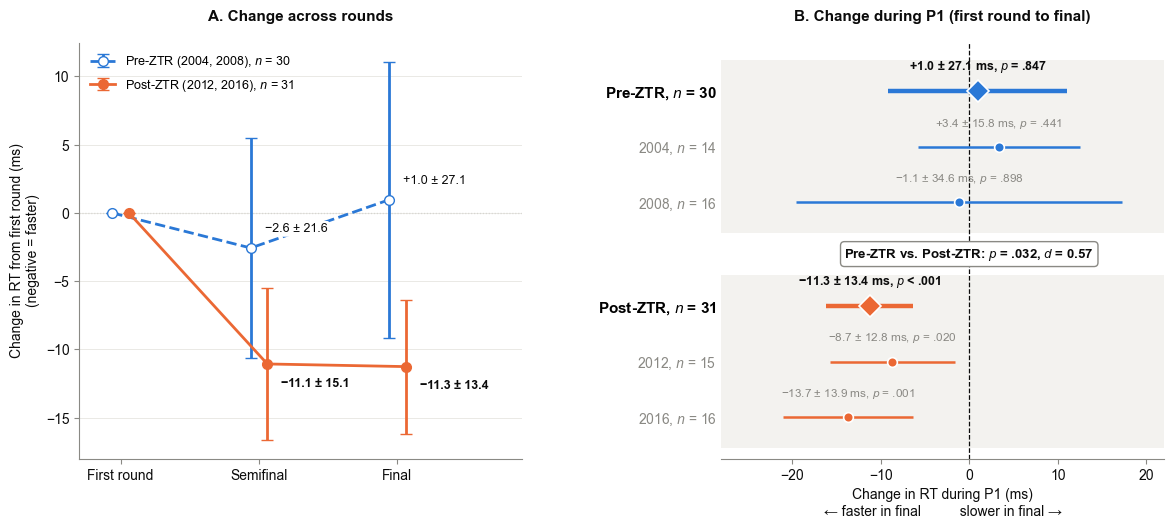

In [ ]:
# ---------- 설정 ----------
ERA_COLOR = {'Pre': '#2a78d6', 'Post': '#eb6834'}
ERA_NAME = {'Pre': 'Pre-ZTR (2004, 2008)', 'Post': 'Post-ZTR (2012, 2016)'}
INK, MUTED, GRID, PANEL = '#0b0b0b', '#8a8984', '#e6e5e0', '#f3f2ef'
TITLE_PAD = 16

ROWS = [('Pre', None), ('Pre', 2004), ('Pre', 2008), ('Post', None), ('Post', 2012), ('Post', 2016)]
Y_POS = [5.5, 4.7, 3.9, 2.4, 1.6, 0.8]


# ---------- 함수 ----------
def mean_ci_t(v):
    """평균, t분포 95% 신뢰구간 반폭, n"""
    v = np.asarray(v, dtype=float)
    n = len(v)
    return v.mean(), stats.t.ppf(0.975, n - 1) * v.std(ddof=1) / np.sqrt(n), n


def fmt_p(p):
    """p를 기울임꼴로: p < .001 / p = .032"""
    return '$p$ < .001' if p < .001 else f'$p$ = {p:.3f}'.replace('0.', '.', 1)


def fmt_num(x, sign=True):
    """하이픈(-) 대신 빼기 기호(−) 사용"""
    s = f'{x:+.1f}' if sign else f'{x:.1f}'
    return s.replace('-', '−')


def style(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelcolor=INK)
    ax.grid(axis='y', color=GRID, lw=0.6)
    ax.set_axisbelow(True)
    ax.axhline(0, color=MUTED, lw=0.8, ls=':', zorder=0)


# ---------- 그림 ----------
with plt.rc_context({'font.family': 'Arial',
                     'mathtext.fontset': 'custom',          # $p$, $n$, $d$ 기울임꼴도 Arial로
                     'mathtext.it': 'Arial:italic',
                     'mathtext.rm': 'Arial',
                     'axes.unicode_minus': True}):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.4),
                                   gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.45})

    # ===== A. 라운드별 평균 흐름 (1라운드 = 0) =====
    x = np.arange(3)
    LABEL_OFFSET = {'Pre': (0.10, 1.4), 'Post': (0.10, -1.4)}
    for era in ERA_ORDER:
        d = change_df[change_df['Era'] == era]
        means, cis, sds = [0.0], [0.0], [0.0]
        for col in ['d_front', 'd_total']:        # P2 (R1→준결승), P1 (R1→결승)
            m, ci, _ = mean_ci_t(d[col])
            means.append(m)
            cis.append(ci)
            sds.append(d[col].std(ddof=1))
        off = -0.06 if era == 'Pre' else 0.06
        axA.errorbar(x + off, means, yerr=cis, color=ERA_COLOR[era], marker='o', ms=7, lw=2,
                     capsize=4, ls='--' if era == 'Pre' else '-',
                     mfc='white' if era == 'Pre' else ERA_COLOR[era],
                     label=f'{ERA_NAME[era]}, $n$ = {len(d)}')
        dx, dy = LABEL_OFFSET[era]
        for xi, m, sd in zip(x[1:] + off, means[1:], sds[1:]):
            axA.text(xi + dx, m + dy, f'{fmt_num(m)} ± {sd:.1f}', va='center', fontsize=9,
                     color=INK, fontweight='bold' if era == 'Post' else 'normal',
                     bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'))
    axA.set_xticks(x)
    axA.set_xticklabels(['First round', 'Semifinal', 'Final'])
    axA.set_xlim(-0.3, 2.9)
    axA.set_ylabel('Change in RT from first round (ms)\n(negative = faster)', color=INK)
    axA.set_title('A. Change across rounds', loc='center', fontsize=11, fontweight='bold',
                  color=INK, pad=TITLE_PAD)
    axA.legend(frameon=False, fontsize=9, loc='upper left')
    style(axA)

    # ===== B. 포레스트 플롯: P1 변화, 전체(◆) + 대회별(●) =====
    # Pre-ZTR 묶음, Post-ZTR 묶음 뒤에 연한 배경
    axB.axhspan(3.45, 5.95, color=PANEL, zorder=0, lw=0)
    axB.axhspan(0.35, 2.85, color=PANEL, zorder=0, lw=0)

    ylabels = []
    for (era, yr), y in zip(ROWS, Y_POS):
        d = change_df[change_df['Era'] == era] if yr is None else change_df[change_df['Year'] == yr]
        v = d['d_total'].to_numpy(dtype=float)
        m, ci, n = mean_ci_t(v)
        sd = v.std(ddof=1)
        _, p = stats.ttest_1samp(v, 0)              # P1 변화 vs 0 (= 대응표본 t검정)
        pooled = yr is None

        axB.hlines(y, m - ci, m + ci, color=ERA_COLOR[era], lw=3.2 if pooled else 1.8, zorder=2)
        axB.plot(m, y, marker='D' if pooled else 'o', ms=11 if pooled else 7, color=ERA_COLOR[era],
                 mec='white', mew=1.2, zorder=3)
        axB.text(m, y + 0.24, f'{fmt_num(m)} ± {sd:.1f} ms, {fmt_p(p)}', ha='center', va='bottom',
                 fontsize=9 if pooled else 8.5,
                 color=INK if pooled else MUTED, fontweight='bold' if pooled else 'normal')

        name = f'{era}-ZTR' if pooled else str(yr)
        ylabels.append(f'{name}, $n$ = {n}')

    axB.set_yticks(Y_POS)
    axB.set_yticklabels(ylabels)
    for lab, (era, yr) in zip(axB.get_yticklabels(), ROWS):
        if yr is None:
            lab.set_fontweight('bold')
            lab.set_fontsize(11)
        else:
            lab.set_color(MUTED)
    axB.set_ylim(0.2, 6.2)
    axB.set_xlim(-28, 22)
    axB.axvline(0, color=INK, lw=0.9, ls='--', zorder=1)
    axB.set_xlabel('Change in RT during P1 (ms)\n← faster in final          slower in final →',
                   color=INK)
    axB.spines[['top', 'right', 'left']].set_visible(False)
    axB.spines['bottom'].set_color(MUTED)
    axB.tick_params(axis='y', length=0)
    axB.tick_params(axis='x', colors=MUTED, labelcolor=INK)

    # Pre-ZTR vs. Post-ZTR 비교: 두 묶음 사이 상자
    pre = change_df.loc[change_df['Era'] == 'Pre', 'd_total']
    post = change_df.loc[change_df['Era'] == 'Post', 'd_total']
    _, p_between = stats.ttest_ind(pre, post, equal_var=False)
    axB.text(0, 3.15, f'Pre-ZTR vs. Post-ZTR: {fmt_p(p_between)}, $d$ = {abs(cohens_d(pre, post)):.2f}',
             ha='center', va='center', fontsize=9.5, fontweight='bold', color=INK, zorder=4,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=MUTED))

    axB.set_title('B. Change during P1 (first round to final)', loc='center', fontsize=11,
                  fontweight='bold', color=INK, pad=TITLE_PAD)

    plt.savefig('figure1.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()